In [1]:
import pandas as pd

df = pd.read_csv("SuperStore_Sales_Dataset.csv")

# Drop useless columns
df.drop(columns=['ind1', 'ind2', 'Returns'], inplace=True, errors='ignore')

# Rename column
df.rename(columns={'Row ID+O6G3A1:R6': 'Row ID'}, inplace=True)

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         5901 non-null   int64         
 1   Order ID       5901 non-null   object        
 2   Order Date     5901 non-null   datetime64[ns]
 3   Ship Date      5901 non-null   datetime64[ns]
 4   Ship Mode      5901 non-null   object        
 5   Customer ID    5901 non-null   object        
 6   Customer Name  5901 non-null   object        
 7   Segment        5901 non-null   object        
 8   Country        5901 non-null   object        
 9   City           5901 non-null   object        
 10  State          5901 non-null   object        
 11  Region         5901 non-null   object        
 12  Product ID     5901 non-null   object        
 13  Category       5901 non-null   object        
 14  Sub-Category   5901 non-null   object        
 15  Product Name   5901 n

In [2]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Profit Margin'] = df['Profit'] / df['Sales']

In [3]:
print("Total Sales:", df['Sales'].sum())
print("Total Profit:", df['Profit'].sum())
print("Total Orders:", df['Order ID'].nunique())

Total Sales: 1565804.3232
Total Profit: 175262.1059
Total Orders: 3003


In [4]:
df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

,Sales,Profit
Category,,
Office Supplies,643707.6870,74797.2461
Technology,470587.9910,90458.2486
Furniture,451508.6452,10006.6112


In [5]:
df.groupby('Region')[['Sales', 'Profit']].sum()

,Sales,Profit
Region,,
Central,341007.5242,27450.0071
East,450234.6660,53400.4243
South,252121.0810,26551.7163
West,522441.0520,67859.9582


In [6]:
df.groupby(['Year', 'Month'])['Sales'].sum()

Year  Month
2019  1         18616.4310
      2         19978.8150
      3         51715.8750
      4         38750.0390
      5         50987.7280
      6         40344.5340
      7         39261.9630
      8         31115.3743
      9         73410.0249
      10        42687.7450
      11        79411.9658
      12        78399.0430
2020  1         54763.3740
      2         52068.1334
      3         64229.3528
      4         50807.5361
      5         66750.1102
      6         69242.7257
      7         60077.4160
      8         77338.8880
      9        119803.6520
      10        88896.9232
      11       130960.8250
      12       166185.8488
Name: Sales, dtype: float64

In [7]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

Customer Name
Caroline Jumper    11596.974
Karen Ferguson     10941.274
Seth Vernon        10751.148
Helen Wasserman    10074.934
Edward Hooks        9542.988
Bill Shonely        9199.780
Pete Kriz           8812.054
John Lee            8765.332
Adam Bellavance     8167.080
Jane Waco           7933.554
Name: Sales, dtype: float64

In [8]:
df[df['Profit'] < 0].sort_values(by='Profit').head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Profit,Payment Mode,Year,Month,Month Name,Profit Margin
2184,7773,CA-2019-108196,2019-11-25,2019-12-02,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,...,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,-6599.9780,Cards,2019,11,November,-1.466667
5037,684,US-2020-168116,2020-11-04,2020-11-04,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,...,Machines,Cubify CubeX 3D Printer Triple Head Print,3009.980,4,-3839.9904,Online,2020,11,November,-1.275753
3193,3012,CA-2020-134845,2020-04-17,2020-04-23,Standard Class,SR-20425,Sharelle Roach,Home Office,United States,Louisville,...,Machines,Lexmark MX611dhe Monochrome Laser Printer,2579.985,5,-3399.9800,COD,2020,4,April,-1.317829
5569,4992,US-2020-122714,2020-12-07,2020-12-13,Standard Class,HG-14965,Henry Goldwyn,Corporate,United States,Chicago,...,Binders,Ibico EPK-21 Electric Binding System,1901.990,5,-2929.4845,COD,2020,12,December,-1.540221
5276,5311,CA-2020-131254,2020-11-19,2020-11-21,First Class,NC-18415,Nathan Cano,Consumer,United States,Houston,...,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,1556.188,6,-2287.7820,COD,2020,11,November,-1.470119
383,1200,CA-2019-130946,2019-04-08,2019-04-12,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Houston,...,Binders,GBC DocuBind P400 Electric Binding System,1088.792,4,-1850.9464,Online,2019,4,April,-1.700000
4845,2929,US-2020-120390,2020-10-19,2020-10-26,Standard Class,TH-21550,Tracy Hopkins,Home Office,United States,Burlington,...,Binders,GBC DocuBind P400 Electric Binding System,1677.188,4,-1306.5504,COD,2020,10,October,-0.779012
4075,7899,CA-2020-128363,2020-08-13,2020-08-18,Standard Class,DC-12850,Dan Campbell,Consumer,United States,Memphis,...,Binders,GBC DocuBind TL300 Electric Binding System,1641.582,6,-1237.8462,Cards,2020,8,August,-0.754057
4384,2847,CA-2020-152093,2020-09-10,2020-09-15,Standard Class,SN-20560,Skye Norling,Home Office,United States,Chicago,...,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,804.594,3,-1143.8910,COD,2020,9,September,-1.421700
2618,8641,US-2020-148551,2020-01-12,2020-01-16,Standard Class,DB-13120,David Bremer,Corporate,United States,Dallas,...,Binders,GBC Ibimaster 500 Manual ProClick Binding System,790.980,5,-1141.4700,Cards,2020,1,January,-1.443109


In [9]:
df[df['Profit'] < 0].sort_values(by='Profit').head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Profit,Payment Mode,Year,Month,Month Name,Profit Margin
2184,7773,CA-2019-108196,2019-11-25,2019-12-02,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,...,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,-6599.9780,Cards,2019,11,November,-1.466667
5037,684,US-2020-168116,2020-11-04,2020-11-04,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,...,Machines,Cubify CubeX 3D Printer Triple Head Print,3009.980,4,-3839.9904,Online,2020,11,November,-1.275753
3193,3012,CA-2020-134845,2020-04-17,2020-04-23,Standard Class,SR-20425,Sharelle Roach,Home Office,United States,Louisville,...,Machines,Lexmark MX611dhe Monochrome Laser Printer,2579.985,5,-3399.9800,COD,2020,4,April,-1.317829
5569,4992,US-2020-122714,2020-12-07,2020-12-13,Standard Class,HG-14965,Henry Goldwyn,Corporate,United States,Chicago,...,Binders,Ibico EPK-21 Electric Binding System,1901.990,5,-2929.4845,COD,2020,12,December,-1.540221
5276,5311,CA-2020-131254,2020-11-19,2020-11-21,First Class,NC-18415,Nathan Cano,Consumer,United States,Houston,...,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,1556.188,6,-2287.7820,COD,2020,11,November,-1.470119
383,1200,CA-2019-130946,2019-04-08,2019-04-12,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Houston,...,Binders,GBC DocuBind P400 Electric Binding System,1088.792,4,-1850.9464,Online,2019,4,April,-1.700000
4845,2929,US-2020-120390,2020-10-19,2020-10-26,Standard Class,TH-21550,Tracy Hopkins,Home Office,United States,Burlington,...,Binders,GBC DocuBind P400 Electric Binding System,1677.188,4,-1306.5504,COD,2020,10,October,-0.779012
4075,7899,CA-2020-128363,2020-08-13,2020-08-18,Standard Class,DC-12850,Dan Campbell,Consumer,United States,Memphis,...,Binders,GBC DocuBind TL300 Electric Binding System,1641.582,6,-1237.8462,Cards,2020,8,August,-0.754057
4384,2847,CA-2020-152093,2020-09-10,2020-09-15,Standard Class,SN-20560,Skye Norling,Home Office,United States,Chicago,...,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,804.594,3,-1143.8910,COD,2020,9,September,-1.421700
2618,8641,US-2020-148551,2020-01-12,2020-01-16,Standard Class,DB-13120,David Bremer,Corporate,United States,Dallas,...,Binders,GBC Ibimaster 500 Manual ProClick Binding System,790.980,5,-1141.4700,Cards,2020,1,January,-1.443109


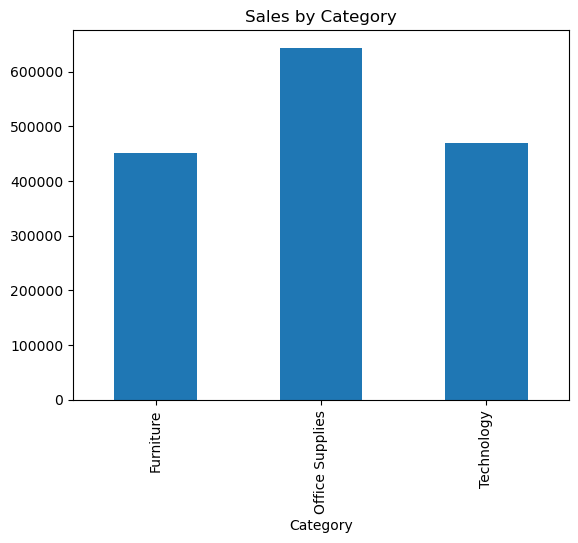

In [10]:
import matplotlib.pyplot as plt

df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

In [16]:
import pandas as pd
import sqlite3

# Load clean data
df = pd.read_csv("SuperStore_Sales_Dataset.csv")

# Fix date format (DD-MM-YYYY)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Add columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

# Recreate database
conn = sqlite3.connect("superstore.db")
df.to_sql("superstore", conn, if_exists="replace", index=False)
print("Database recreated!")
print("Columns:", list(df.columns))

Database recreated!
Columns: ['Row ID+O6G3A1:R6', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Profit', 'Returns', 'Payment Mode', 'ind1', 'ind2', 'Year', 'Month', 'Month Name', 'Profit Margin']


In [17]:
# 1. Total Sales & Profit by Region
q1 = pd.read_sql("""
    SELECT Region, 
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profit
    FROM superstore
    GROUP BY Region
    ORDER BY Total_Sales DESC
""", conn)
print("--- Sales by Region ---")
print(q1)

# 2. Top 10 Products by Sales
q2 = pd.read_sql("""
    SELECT "Product Name", 
           ROUND(SUM(Sales), 2) AS Total_Sales
    FROM superstore
    GROUP BY "Product Name"
    ORDER BY Total_Sales DESC
    LIMIT 10
""", conn)
print("\n--- Top 10 Products ---")
print(q2)

# 3. Monthly Sales Trend
q3 = pd.read_sql("""
    SELECT Year, Month,
           ROUND(SUM(Sales), 2) AS Monthly_Sales
    FROM superstore
    GROUP BY Year, Month
    ORDER BY Year, Month
""", conn)
print("\n--- Monthly Trend ---")
print(q3)

# 4. Sales by Category
q4 = pd.read_sql("""
    SELECT Category, "Sub-Category",
           ROUND(SUM(Sales), 2) AS Sales,
           ROUND(SUM(Profit), 2) AS Profit
    FROM superstore
    GROUP BY Category, "Sub-Category"
    ORDER BY Sales DESC
""", conn)
print("\n--- Category Breakdown ---")
print(q4)

# 5. Sales by Payment Mode
q5 = pd.read_sql("""
    SELECT "Payment Mode",
           ROUND(SUM(Sales), 2) AS Total_Sales,
           COUNT(*) AS Total_Orders
    FROM superstore
    GROUP BY "Payment Mode"
    ORDER BY Total_Sales DESC
""", conn)
print("\n--- Payment Mode ---")
print(q5)

conn.close()
print("\nAll queries done!")

--- Sales by Region ---
    Region  Total_Sales  Total_Profit
0     West    522441.05      67859.96
1     East    450234.67      53400.42
2  Central    341007.52      27450.01
3    South    252121.08      26551.72

--- Top 10 Products ---
                                        Product Name  Total_Sales
0   3D Systems Cube Printer, 2nd Generation, Magenta     14334.89
1              Canon imageCLASS 2200 Advanced Copier     14076.82
2               Hewlett Packard LaserJet 3310 Copier     13837.73
3         GBC DocuBind TL300 Electric Binding System     12890.26
4          GBC DocuBind P400 Electric Binding System     12577.11
5                            Samsung Galaxy Mega 6.3     12370.71
6  Martin Yale Chadless Opener Electric Letter Op...     12268.90
7       HON 5400 Series Task Chairs for Big and Tall     11887.56
8      Global Troy Executive Leather Low-Back Tilter     10217.89
9  Fellowes PB500 Electric Punch Plastic Comb Bin...      9756.52

--- Monthly Trend ---
    Year  Mo